# Machine Learning Forecasting: ERCOT Electricity Demand
- This notebook builds machine learning forecasting models using lag, rolling, calendar, and trend-based features.
- The goal is to compare machine learning models against prior statistical forecasting results and the EIA forecast benchmark.

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

## 2. Load Data (Same as "03_statistical_forecasting" Notebook)

In [ ]:
BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Ercot_Electric_Demand")
PROCESSED_DIR = BASE_DIR/"data" / "processed"

df = pd.read_csv(PROCESSED_DIR / "ercot_daily_wide.csv", parse_dates=["period"])

df = df.sort_values("period")
df = df.set_index("period")
df = df.asfreq("D")

target = "demand"

df_model = df.dropna(subset=[target]).copy()

df_model.head()

,demand,demand_forecast,net_generation,demand_count,demand_forecast_count,net_generation_count
period,,,,,,
2019-01-01,950405.0,932790.0,951051.0,24.0,24.0,24.0
2019-01-02,1093650.0,1038403.0,1091777.0,24.0,24.0,24.0
2019-01-03,1119840.0,1084163.0,1120374.0,24.0,24.0,24.0
2019-01-04,1065428.0,1086500.0,1067670.0,24.0,24.0,24.0
2019-01-05,931268.0,948521.0,935034.0,24.0,24.0,24.0


## 3. Evaluation Function

In [ ]:
def evaluate(y_true, y_pred, name="Model"):
  eval_df = pd.concat([y_true, y_pred], axis=1).dropna()
  eval_df.columns = ["actual", "predicted"]

  mae = mean_absolute_error(eval_df["actual"], eval_df["predicted"])
  rmse = np.sqrt(mean_squared_error(eval_df["actual"], eval_df["predicted"]))
  mape = np.mean(np.abs((eval_df["actual"] - eval_df["predicted"]) / eval_df["actual"])) * 100

  print(f"{name}")
  print(f"MAE: {mae:.2f}")
  print(f"RMSE: {rmse:.2f}")
  print(f"MAPE: {mape:.2f}%")
  print("-" * 30)

  return mae, rmse, mape

## 4. Feature Engineering

To enable machine learning models to capture temporal patterns, the following features were created:

- **Lag Features**: Capture recent demand behavior (short-term dependency)
- **Rolling Statistics**: Smooth demand patterns and capture local trends
- **Calendar Features**: Represent weekly and seasonal effects
- **Trend Feature (`time_index`)**: Capture long-term trend

Lag and rolling features introduce missing values at the beginning of the dataset due to insufficient history. These rows are removed to ensure all features are fully defined.

In [ ]:
# Lag features
for lag in [1, 2, 3, 7, 14, 21, 30]:
    df_model[f"lag_{lag}"] = df_model[target].shift(lag)

# Rolling features
df_model["rolling_mean_7"] = df_model[target].rolling(7).mean().shift(1)
df_model["rolling_std_7"] = df_model[target].rolling(7).std().shift(1)

df_model["rolling_mean_14"] = df_model[target].rolling(14).mean().shift(1)
df_model["rolling_std_14"] = df_model[target].rolling(14).std().shift(1)

df_model["rolling_mean_30"] = df_model[target].rolling(30).mean().shift(1)

# Calendar features
df_model["day_of_week"] = df_model.index.dayofweek
df_model["month"] = df_model.index.month
df_model["day_of_year"] = df_model.index.dayofyear
df_model["is_weekend"] = df_model["day_of_week"].isin([5, 6]).astype(int)

# Trend feature
df_model["time_index"] = np.arange(len(df_model))

df_model = df_model.dropna().copy()

df_model.head()

,demand,demand_forecast,net_generation,demand_count,demand_forecast_count,net_generation_count,lag_1,lag_2,lag_3,lag_7,...,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,day_of_week,month,day_of_year,is_weekend,time_index
period,,,,,,,,,,,,,,,,,,,,,
2019-01-31,1000031.0,994943.0,1016471.0,24.0,24.0,24.0,1054071.0,1009411.0,907776.0,1082965.0,...,980736.000000,77659.298791,966465.428571,75468.307213,959813.566667,3,1,31,0,30
2019-02-01,886847.0,897526.0,896241.0,24.0,24.0,24.0,1000031.0,1054071.0,1009411.0,1006154.0,...,968888.285714,64710.574071,975352.357143,71148.831353,961467.766667,4,2,32,0,31
2019-02-02,824947.0,820732.0,827692.0,24.0,24.0,24.0,886847.0,1000031.0,1054071.0,927770.0,...,951844.428571,68839.593762,974928.142857,71694.601309,954574.333333,5,2,33,1,32
2019-02-03,796136.0,780621.0,793554.0,24.0,24.0,24.0,824947.0,886847.0,1000031.0,877005.0,...,937155.428571,84109.403196,969050.071429,80503.435444,944744.566667,6,2,34,1,33
2019-02-04,834852.0,835041.0,832303.0,24.0,24.0,24.0,796136.0,824947.0,886847.0,907776.0,...,925602.714286,98132.987116,951060.714286,89179.180201,935768.166667,0,2,35,0,34


## 5. Train / Validation / Test Split

In [ ]:
train_size = int(len(df_model) * 0.7)
val_size = int(len(df_model) * 0.15)

train = df_model.iloc[:train_size]
val = df_model.iloc[train_size:train_size + val_size]
test = df_model.iloc[train_size + val_size:]

print(len(train), len(val), len(test))

1827 391 393


## 6. Feature Selection

Two feature sets are created:

- **XGBoost (with Net Generation)**: Includes contemporaneous net generation as an input feature
- **XGBoost (Lag-Based Features Only)**: Uses only historical features to simulate a true forecasting scenario

This allows comparison between enriched models and realistic forecasting conditions.

In [ ]:
exclude_cols = [
    target,
    "demand_forecast_count",
    "net_generation_count",
    "demand_count"
]

features = [col for col in df_model.columns if col not in exclude_cols]

features

['demand_forecast',
 'net_generation',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_7',
 'lag_14',
 'lag_21',
 'lag_30',
 'rolling_mean_7',
 'rolling_std_7',
 'rolling_mean_14',
 'rolling_std_14',
 'rolling_mean_30',
 'day_of_week',
 'month',
 'day_of_year',
 'is_weekend',
 'time_index']

In [ ]:
# Removing EIA demand forecast
features_no_eia = [
    col for col in features
    if col not in ["demand_forecast"]
]

model_features = features_no_eia

In [ ]:
# Removing EIA demand forecast and net generation
features_lagBased = [
    col for col in model_features
    if col not in ["net_generation", "demand_forecast"]
]

## 7. Assign Features Train/Test

In [ ]:
X_train = train[model_features]
y_train = train[target]

X_test = test[model_features]
y_test = test[target]

In [ ]:
X_train_lagBased = train[features_lagBased]
X_test_lagBased = test[features_lagBased]

## 8. XGBoost Model

XGBoost is used as the primary machine learning model due to its ability to capture nonlinear relationships and interactions between features.

Two versions are trained:
- With net generation (enriched model)
- Without contemporaneous variables (lag-based model)

This comparison highlights the impact of feature availability on forecasting performance.

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_forecast = pd.Series(
    xgb_pred,
    index=test.index,
    name="xgboost_forecast"
)

evaluate(y_test, xgb_forecast, "XGBoost")

XGBoost
MAE: 8349.27
RMSE: 28442.13
MAPE: 0.63%
------------------------------


(8349.273536895675,
 np.float64(28442.131313701713),
 np.float64(0.6314504289048741))

In [ ]:
xgb_model_lagBased = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model_lagBased.fit(X_train_lagBased, y_train)

xgb_pred_lagBased = xgb_model_lagBased.predict(X_test_lagBased)

xgb_forecast_lagBased = pd.Series(
    xgb_pred_lagBased,
    index=test.index,
    name="xgboost_lag-Based_forecast"
)

## 9. Linear Trend Baseline
### Trend Modeling Approach

- A linear regression model is used with only the `time_index` feature to explicitly capture the long-term trend in electricity demand.
- Tree-based models such as XGBoost do not naturally extrapolate trends beyond the range of observed data. In contrast, linear regression can model and extend a global trend over time.
- For this reason, the trend component is modeled separately using a simple linear model, while XGBoost is later used to capture nonlinear patterns and short-term fluctuations.

In [ ]:
trend_features = ["time_index"]

linear_model = LinearRegression()
linear_model.fit(X_train[trend_features], y_train)

linear_pred = linear_model.predict(X_test[trend_features])

linear_forecast = pd.Series(
    linear_pred,
    index=test.index,
    name="linear_trend_forecast"
)

evaluate(y_test, linear_forecast, "Linear Trend")

Linear Trend
MAE: 156258.99
RMSE: 176413.68
MAPE: 11.83%
------------------------------


(156258.9943523863,
 np.float64(176413.6792520533),
 np.float64(11.830858501268358))

## 10. Hybrid Model: Linear Trend + XGBoost Residuals

The hybrid model separates the forecasting problem into:

- **Trend Component (Linear Regression)**: Captures long-term behavior
- **Residual Component (XGBoost)**: Captures nonlinear and short-term variations

Final predictions are obtained by combining both components.

This approach allows combining extrapolation capability with flexible pattern learning.

In [ ]:
# Fit trend model on training data
trend_model = LinearRegression()
trend_model.fit(X_train[["time_index"]], y_train)

train_trend_pred = trend_model.predict(X_train[["time_index"]])
test_trend_pred = trend_model.predict(X_test[["time_index"]])

# Calculate training residuals
train_residuals = y_train - train_trend_pred

# Train XGBoost on residuals
residual_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

residual_model.fit(X_train, train_residuals)

test_residual_pred = residual_model.predict(X_test)

hybrid_pred = test_trend_pred + test_residual_pred

hybrid_forecast = pd.Series(
    hybrid_pred,
    index=test.index,
    name="hybrid_forecast"
)

evaluate(y_test, hybrid_forecast, "Hybrid Linear Trend + XGBoost Residuals")

Hybrid Linear Trend + XGBoost Residuals
MAE: 97448.76
RMSE: 99505.15
MAPE: 7.44%
------------------------------


(97448.75755358838,
 np.float64(99505.15457803631),
 np.float64(7.444057873505819))

In [ ]:
hybrid_forecast.head()

,hybrid_forecast
period,
2025-02-27,1.148345e+06
2025-02-28,1.150620e+06
2025-03-01,1.118149e+06
2025-03-02,1.108138e+06
2025-03-03,1.155147e+06


## 11. EIA Forecast Benchmark

In [ ]:
evaluate(y_test, test["demand_forecast"], "EIA Forecast")

EIA Forecast
MAE: 26481.41
RMSE: 82574.84
MAPE: 2.05%
------------------------------


(26481.41221374046,
 np.float64(82574.83609123084),
 np.float64(2.050323167280728))

## 12. Feature Importance

In [ ]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=model_features,
    name = "Feature_Importance"
).sort_values(ascending=False)

importance.head(15)

,Feature_Importance
net_generation,0.596286
lag_1,0.240223
rolling_mean_7,0.132413
is_weekend,0.005602
lag_2,0.004495
day_of_week,0.003690
rolling_mean_14,0.003061
month,0.002408
rolling_std_7,0.002285
day_of_year,0.002203


In [ ]:
importance_lagBased = pd.Series(
    xgb_model_lagBased.feature_importances_,
    index=features_lagBased,   # ✔ correct
    name="Feature_Importance_Lag-Based"
).sort_values(ascending=False)

importance.head(15)

,Feature_Importance
net_generation,0.596286
lag_1,0.240223
rolling_mean_7,0.132413
is_weekend,0.005602
lag_2,0.004495
day_of_week,0.003690
rolling_mean_14,0.003061
month,0.002408
rolling_std_7,0.002285
day_of_year,0.002203


### 12.1 Feature Importance Interpretation
The following plot highlights the most influential features used by the XGBoost model.
- **Net generation** is the most influential feature in the enriched model, indicating a strong relationship with demand.
- **Lag features (especially lag_1)** confirm that electricity demand is highly dependent on recent values.
- **Rolling features** help smooth variability and improve predictions.
- **Calendar features** contribute to modeling weekly patterns but have lower importance.

For the lag-based model, importance shifts more toward lag and rolling features, highlighting reliance on historical demand patterns.

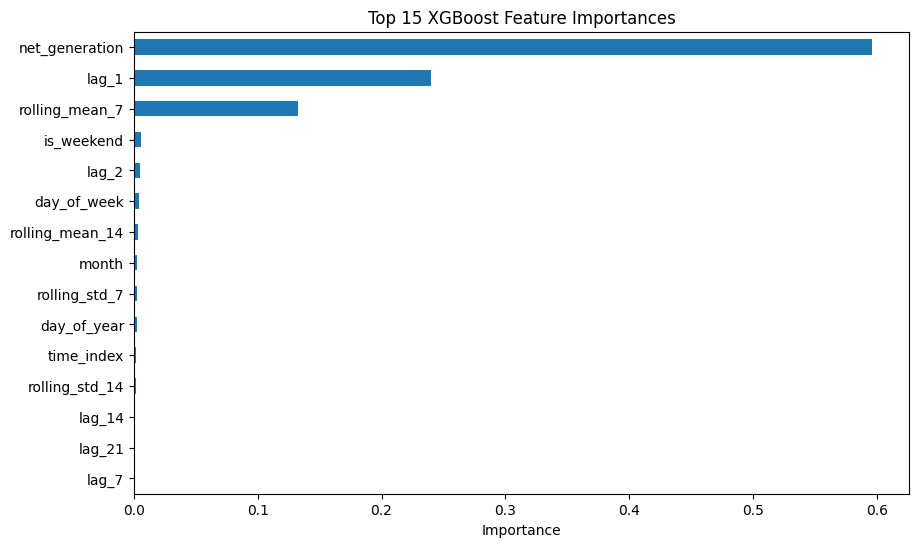

In [ ]:
plt.figure(figsize=(10,6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

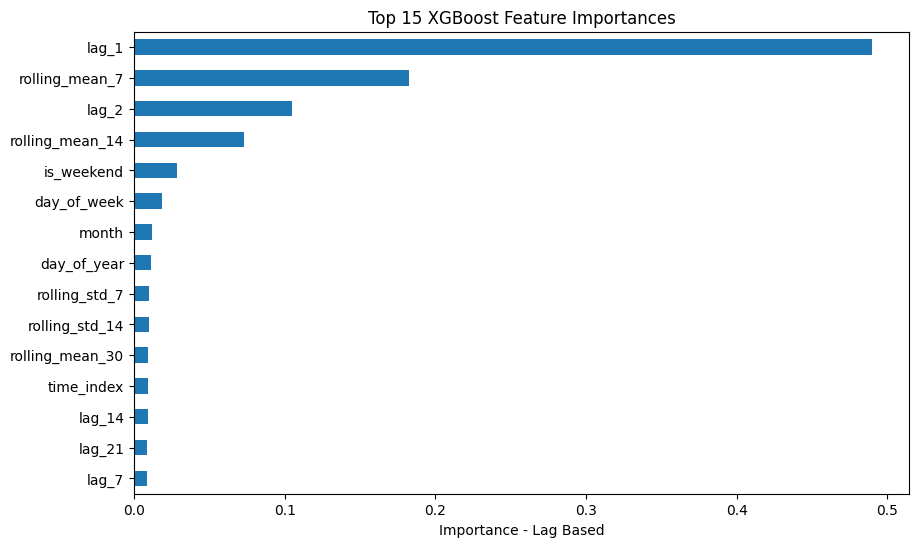

In [ ]:
plt.figure(figsize=(10,6))
importance_lagBased.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance - Lag Based")
plt.show()

## 13. Forecast Comparison: ML Models vs EIA Forecast

The plot below compares actual demand against:

- XGBoost (with net generation)
- XGBoost (Lag-Based Features Only)
- Hybrid model
- EIA forecast benchmark

This comparison illustrates how model performance varies based on feature availability and demonstrates the trade-off between enriched inputs and realistic forecasting constraints.

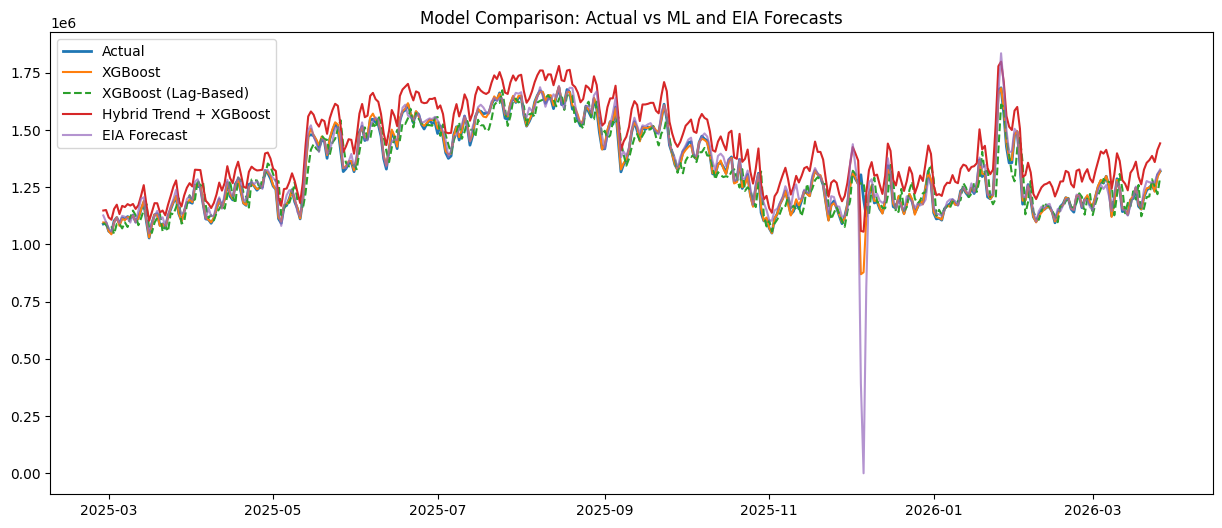

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(test.index, y_test, label="Actual", linewidth=2)
plt.plot(test.index, xgb_forecast, label="XGBoost")
plt.plot(test.index, xgb_forecast_lagBased, label="XGBoost (Lag-Based)", linestyle="--")
plt.plot(test.index, hybrid_forecast, label="Hybrid Trend + XGBoost")
plt.plot(test.index, test["demand_forecast"], label="EIA Forecast", alpha=0.7)

plt.legend()
plt.title("Model Comparison: Actual vs ML and EIA Forecasts")
plt.show()

## 14. Model Comparison Table

The table below summarizes model performance using MAE, RMSE, and MAPE.

This allows direct comparison between:
- Machine learning models
- Hybrid model
- Real-world benchmark (EIA)

In [ ]:
comparison_results = []

models = {
    "XGBoost (with Net Generation)": xgb_forecast,
    "XGBoost (Lag-Based Features Only)": xgb_forecast_lagBased,
    "Linear Trend": linear_forecast,
    "Hybrid Trend + XGBoost": hybrid_forecast,
    "EIA Forecast": test["demand_forecast"]
}

for name, preds in models.items():
    mae, rmse, mape = evaluate(y_test, preds, name)
    comparison_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

comparison_df = pd.DataFrame(comparison_results).sort_values("MAPE")
comparison_df

XGBoost (with Net Generation)
MAE: 8349.27
RMSE: 28442.13
MAPE: 0.63%
------------------------------
XGBoost (Lag-Based Features Only)
MAE: 42293.08
RMSE: 55574.96
MAPE: 3.22%
------------------------------
Linear Trend
MAE: 156258.99
RMSE: 176413.68
MAPE: 11.83%
------------------------------
Hybrid Trend + XGBoost
MAE: 97448.76
RMSE: 99505.15
MAPE: 7.44%
------------------------------
EIA Forecast
MAE: 26481.41
RMSE: 82574.84
MAPE: 2.05%
------------------------------


,Model,MAE,RMSE,MAPE
0,XGBoost (with Net Generation),8349.273537,28442.131314,0.631450
4,EIA Forecast,26481.412214,82574.836091,2.050323
1,XGBoost (Lag-Based Features Only),42293.076495,55574.961767,3.217929
3,Hybrid Trend + XGBoost,97448.757554,99505.154578,7.444058
2,Linear Trend,156258.994352,176413.679252,11.830859


## 15. Key Findings
## Key Findings

### Model Performance

- The XGBoost model with net generation achieved the best performance (MAPE ≈ 0.63%), significantly outperforming all other models.
- The EIA forecast remained a strong real-world benchmark (MAPE ≈ 2.05%).
- The lag-based XGBoost model (using only historical features) achieved MAPE ≈ 3.22%, demonstrating strong performance under realistic forecasting constraints.
- The hybrid model (Linear Trend + XGBoost Residuals) underperformed standalone XGBoost (MAPE ≈ 7.44%), indicating that explicit trend decomposition did not improve results for this dataset.
- The linear trend model alone performed poorly (MAPE ≈ 11.83%), confirming that electricity demand is not driven by a simple linear trend.


### Impact of Feature Availability

- Including contemporaneous **net generation** dramatically improved model performance.
  - However, net generation may not always be available in true forecasting scenarios, making the lag-based model a more realistic benchmark.
- The gap between enriched and lag-based models highlights the importance of feature availability in time series forecasting.


### Comparison with EIA Forecast

- The EIA forecast outperformed the lag-based model but was outperformed by the enriched XGBoost model.
- This suggests that incorporating highly correlated operational signals (such as net generation) can surpass traditional forecasting approaches.
- Real-world forecasting systems likely benefit from additional external variables such as weather and grid conditions.


### Feature Importance Insights

- Net generation was the most influential feature in the enriched model, indicating a strong relationship with demand.
- Lag features (especially lag_1) were highly important, confirming strong short-term dependency.
- Rolling features helped capture smoothing effects and local patterns.
- Calendar features contributed to weekly structure but had lower importance.

- In the lag-based model, feature importance shifted toward lag and rolling features, highlighting reliance on historical demand patterns.


### Key Observations

- Electricity demand is highly driven by recent values, making lag-based modeling very effective.
- Machine learning models significantly outperform traditional statistical models when combined with feature engineering.
- Feature availability plays a critical role in forecasting accuracy.


### Modeling Takeaways

- SARIMA struggled to capture nonlinear and complex demand patterns.
- XGBoost effectively captured short-term and nonlinear relationships.
- The hybrid approach was conceptually valid but did not provide improvement in this case.
- Separating trend and residual components is useful but dataset-dependent.


### Data Quality Note

- Lag and rolling feature engineering introduced missing values at the beginning of the dataset, which were removed to ensure all features were fully defined.
- A daylight saving time (DST) anomaly identified in preprocessing was handled consistently across modeling steps.


### Next Steps

- Incorporate truly predictive exogenous variables (e.g., weather forecasts).
- Explore hyperparameter tuning and model optimization.
- Transition to a production-ready pipeline with experiment tracking (MLOps).